# Flashzoi/Borzoi

In [1]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import pandas as pd
import src.utils as utils
from torch.amp import autocast
from src.flashzoi import *

## Generate data

Here we create some random dummy data to run tests with.

In [50]:
# Generates a random sequence of ATCG
seq1 = utils.get_random_sequence(length=262145)  
# Generates a new sequence by randomly mutating 1% of the first sequnence
seq2 = utils.get_mutated_sequence(seq1, mutations=0.01)

Mutating 1.0% of sequence


## Run flashzoi

In [29]:
out1 = score_all_tracks(seq1)
out2 = score_all_tracks(seq2)
delta = out2 - out1

print("mean delta:",delta.mean())
print("abs mean delta:",delta.abs().mean())

Mutating 1.0% of sequence


/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/borzoi_pytorch/pytorch_borzoi_model.py:282: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


mean delta: tensor(-0.0418, device='cuda:0')
abs mean delta: tensor(0.0839, device='cuda:0')


## Run PCA on tracks delta

Here we input the delta array after taking the absolute values (since we don't care about directionality, just the amount of change in predictions).

In [51]:
import src.dimreduction as dr

pca_result =  dr.pca_sklearn(delta.abs().cpu())
{k:v.shape for k,v in pca_result.items() if k!="model"}

{'eigenvalues': (100,),
 'eigenvectors': (100, 6144),
 'projections': (7611, 100),
 'explained_variance_ratio': (100,)}

In [52]:
X = pca_result["projections"]
# Convert PCA projections to DataFrame
pca_df = pd.DataFrame(
    X,
    columns=[f"PC{i+1}" for i in range(X.shape[1])]
)
    
# Check that they have the same number of rows
# (assuming that the rows are the same order)
targets = load_targets(species=["human"])
print(targets["source"].value_counts())
assert targets.shape[0] == X.shape[0]
pca_df = pd.concat([targets.reset_index(), pca_df], axis=1)

source
encode      5855
fantom      1276
catlas       222
geo          169
recount3      89
Name: count, dtype: int64


### Get the samples that are driving the delta

We want to now which tissues/cell types are most affected by the mutation(s). We can run a PC on the delta of the two sets of tracks to find this out.

In [72]:
def get_top_loadings(top_n = 5, 
                     groupby_col = "tissue",
                     exp=2,
                     max_pcs = 2):
    top_res = {}
    for i in range(max_pcs):
        pc = f"PC{i+1}"
        top_res[pc] = pca_df.groupby(groupby_col)[pc].apply(lambda x:  (x**exp).mean()).sort_values(ascending=False).head(top_n)
        print(f"\n{pc} ({(pca_result["explained_variance_ratio"][i]*100).round(2)}% variance explained)")
        print(top_res[pc])

#### By assays

In [73]:
top_assays = get_top_loadings(groupby_col="assay")


PC1 (87.59% variance explained)
assay
CHIP     363.994721
CAGE      69.017530
RNA       64.979929
DNASE     55.615131
ATAC      41.956989
Name: PC1, dtype: float64

PC2 (3.97% variance explained)
assay
CHIP     18.753376
CAGE      0.553230
RNA       0.539638
DNASE     0.380827
ATAC      0.276060
Name: PC2, dtype: float64


#### By tissues

In [74]:
top_tissues = get_top_loadings(groupby_col="tissue")


PC1 (87.59% variance explained)
tissue
H3K9me3:CD4-positive, alpha-beta T cell male adult (37 years)    60523.922867
H3K9me3:B cell male adult (37 years)                             47238.633067
H3K9me3:AG04450                                                  43070.360457
H3K9me3:CD14-positive monocyte male adult (21 year)              32474.711206
H3K9me3:stomach female embryo (96 days)                          20385.001326
Name: PC1, dtype: float64

PC2 (3.97% variance explained)
tissue
EZH2:GM23338 male adult (53 years) originated from GM23248                                                      2495.241063
H3K27me3:stomach female embryo (96 days)                                                                        2325.981436
EZH2phosphoT487:bipolar neuron originated from GM23338 treated with 0.5 ug/mL doxycycline hyclate for 4 days    2127.736449
H3K27me3:H1-hESC                                                                                                1678.996249
H3K27me3:

### Get track sample metadata

In [ ]:
# import glob
# pd.set_option('display.max_columns', None)

# # Find all JSON files in the BioSamples directory
# json_files = glob.glob(os.path.expanduser("~/projects/data/BioSamples/*.json"))

# # Read and merge all JSON files into a single DataFrame
# biosamples_dfs = []
# for f in json_files:
#     query = os.path.basename(f).split(".")[0]
#     print(os.path.basename(f))
#     bs = pd.read_json(f) 
#     # Expand the nested characteristics dictionary into separate columns
#     bs = pd.concat([
#         bs.drop('characteristics', axis=1),
#         pd.json_normalize(bs['characteristics'].apply(lambda x: {k: v[0]['text'] if isinstance(v, list) and len(v) > 0 else None for k, v in x.items()}))
#     ], axis=1) 

#     print(bs.shape)
#     # bs = bs.loc[bs["name"].str.startswith("ENCODE")]
#     bs.insert(0,"query", query)
#     bs.insert(0,"id", bs["name"].str.split(" ").str[-1])

#     cols = ["sample type","cell type","tissue", "cell line"]
#     cols = [c for c in cols if c in bs.columns]
#     bs.loc[:,'sample'] = pd.NA
#     bs.loc[:,'sample'] = bs['sample'].fillna(bs[cols[1:]].bfill(axis=1).iloc[:, 0])
    
#     print({c:bs[c].notna().sum() for c in cols+["sample"]})
    
#     bs.fillna({"sample": "other"}, inplace=True)
#     extra_cols = ["id","ENCODE accession","name","sample"]
#     extra_cols = [c for c in extra_cols if c in bs.columns]
#     bs = bs.loc[:,extra_cols+cols]

#     biosamples_dfs.append(bs)

encode.json
(16549, 283)
{'sample type': np.int64(12407), 'cell type': np.int64(1722), 'tissue': np.int64(3903), 'cell line': np.int64(8870), 'sample': np.int64(14443)}
fantom.json
(2228, 198)
{'sample type': np.int64(237), 'cell type': np.int64(93), 'tissue': np.int64(1379), 'cell line': np.int64(344), 'sample': np.int64(1794)}
gtex.json
(49465, 170)
{'cell type': np.int64(553), 'tissue': np.int64(494), 'cell line': np.int64(83), 'sample': np.int64(539)}


Text(0.5, 1.0, 'PCA of FlashZoi Tracks')

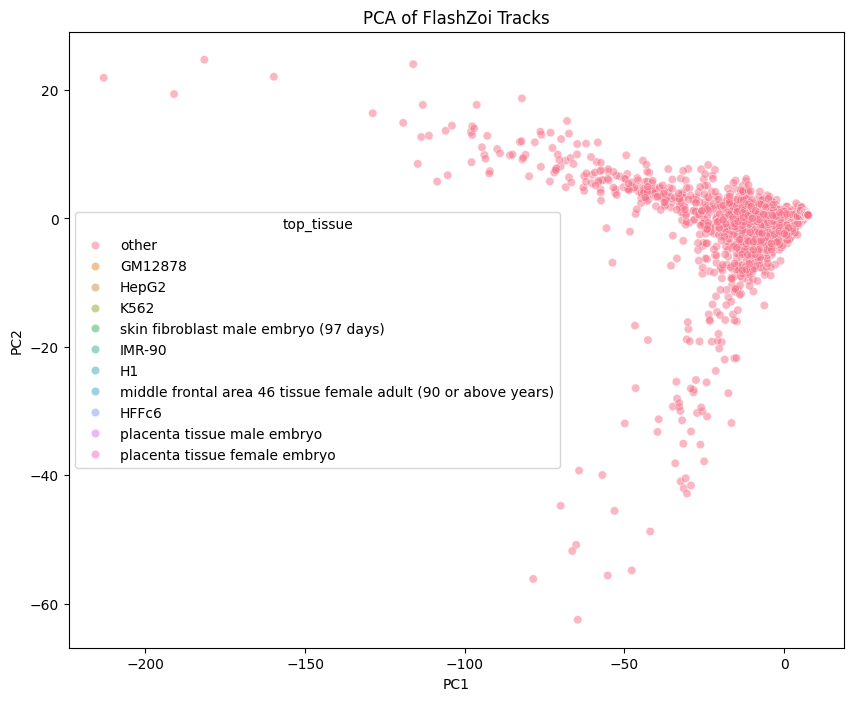

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="top_tissue", alpha=0.5)
plt.title('PCA of FlashZoi Tracks')


## Compute cosine similarity

### Directly on logits

In [199]:
import src.vep_metrics as vm

css = vm.cosine_sim(out1,
                    out2,
                    css_agg_func=None, 
                    # dim=0 returns compute cos sim along the tracks axis
                    # dim=1 returns compute cos sim along the sequence axis
                    dim=0
               )
print(css.shape)
print(css)
print("CSS mean:",css.mean())
print("CSS variance:",css.var())

Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
torch.Size([6144])
tensor([0.9950, 0.9945, 0.9942,  ..., 0.9966, 0.9974, 0.9987], device='cuda:0')
CSS mean: tensor(0.9972, device='cuda:0')
CSS variance: tensor(1.5896e-05, device='cuda:0')


Compute cosin similarity along the tracks axis instead.

In [ ]:
css_ax1 = vm.cosine_sim(out1,
                    out2,
                    css_agg_func=None, 
                    # dim=0 returns compute cos sim along the tracks axis
                    # dim=1 returns compute cos sim along the sequence axis
                    dim=1
               )
print(css_ax1.shape)
print(css_ax1)
print("CSS mean:",css_ax1.mean())
print("CSS variance:",css_ax1.var())

Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
torch.Size([7611])
tensor([0.9297, 0.9461, 0.9057,  ..., 0.9817, 0.9811, 0.9810], device='cuda:0')
CSS mean: tensor(0.9719, device='cuda:0')
CSS variance: tensor(0.0004, device='cuda:0')


### On PCA eigenvectors


Reduce the track predictions from both sequences in one PCA. Then extract the eigenvectors (100 PCs x sequence length) for each sequence and compare them with cosine similarity.

Note: Here we don't want to take the absolute of the track values, because we need to retain info about directionality for comparing the two PCA embeddings afterwards.

In [158]:
pca =  dr.pca_sklearn(torch.concat([out1,out2], axis=1).cpu())

In [227]:
css_pca = {}
for dim in [0,1]:
    print(f"\ndim{dim}")
    res = vm.cosine_sim(pca["eigenvectors"][:,1:out1.shape[1]],
                        pca["eigenvectors"][:,out1.shape[1]+1:],
                        css_agg_func=None, 
                        # dim=0 returns compute cos sim along the sequence axis
                        # dim=1 returns compute cos sim along the 100PC axis
                        dim=dim)
    css_pca[f"dim{dim}"] = res
    print(res.shape)
    # print(res)
    print("CSS mean:",res.mean())
    print("CSS variance:",res.var())


dim0
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
torch.Size([6143])
CSS mean: tensor(0.8918, dtype=torch.float64)
CSS variance: tensor(0.0078, dtype=torch.float64)

dim1
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
torch.Size([100])
CSS mean: tensor(0.8908, dtype=torch.float64)
CSS variance: tensor(0.0007, dtype=torch.float64)


Compute cosin similarity along the sequence axis instead.

In [213]:
pca_ax1 = dr.pca_sklearn(torch.concat([out1,out2], axis=0).cpu())

In [226]:
css_pca_ax1 = {}
for dim in [0,1]:
    print(f"\ndim{dim}")
    res = vm.cosine_sim(pca_ax1["projections"][1:out1.shape[0],:],
                        pca_ax1["projections"][out1.shape[0]+1:,:],
                        css_agg_func=None, 
                        # dim=0 returns compute cos sim along the sequence axis
                        # dim=1 returns compute cos sim along the 100PC axis
                        dim=dim)
    css_pca_ax1[f"dim{dim}"] = res
    print(res.shape)
    # print(res)
    print("CSS mean:",res.mean())
    print("CSS variance:",res.var())


dim0
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
torch.Size([100])
CSS mean: tensor(0.6673, dtype=torch.float64)
CSS variance: tensor(0.0516, dtype=torch.float64)

dim1
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
torch.Size([7610])
CSS mean: tensor(0.9208, dtype=torch.float64)
CSS variance: tensor(0.0199, dtype=torch.float64)


### Compare direct vs. PCA cos sim

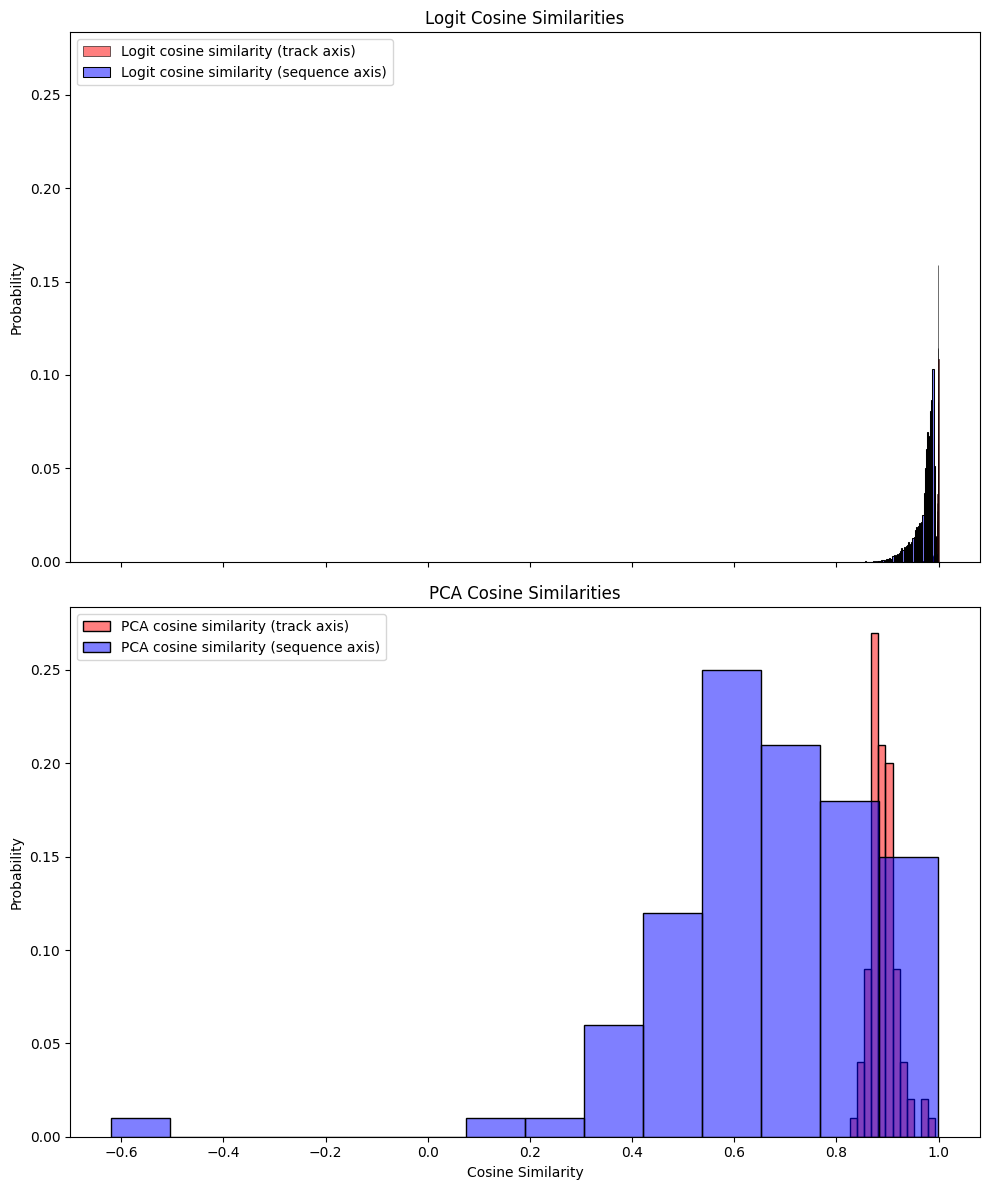

In [215]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), 
                               sharex=True, 
                               sharey=True)

stat="probability"

# Top subplot - Direct cosine similarities
sns.histplot(data=css.cpu(), stat=stat, alpha=0.5, label='Logit cosine similarity (track axis)', color='red', ax=ax1)
sns.histplot(data=css_ax1.cpu(), stat=stat, alpha=0.5, label='Logit cosine similarity (sequence axis)', color='blue', ax=ax1)
ax1.set_xlabel('Cosine Similarity')
ax1.set_title('Logit Cosine Similarities')
ax1.legend(loc='upper left')

# Bottom subplot - PCA cosine similarities
sns.histplot(data=css_pca.cpu(), stat=stat, alpha=0.5, label='PCA cosine similarity (track axis)', color='red', ax=ax2)
sns.histplot(data=css_pca_ax1.cpu(), stat=stat, alpha=0.5, label='PCA cosine similarity (sequence axis)', color='blue', ax=ax2)
ax2.set_xlabel('Cosine Similarity')
ax2.set_title('PCA Cosine Similarities')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()